# 01 - Exploratory Data Analysis
## Dataset exploration, sales analysis, promotion analysis, and visualization

**REPROCESS mode**: This notebook always loads raw data (analysis only, no artifacts saved).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import sys
sys.path.insert(0, str(Path.cwd() / 'notebooks'))
from utils.data import (
    load_transactions, load_products, load_campaign_desc,
    load_campaign_table, load_coupons, load_coupon_redemptions,
    load_causal_data, load_hh_demographic,
)

plt.rcParams['figure.figsize'] = (14, 6)
%matplotlib inline

In [3]:
transactions = load_transactions()
products = load_products()
# campaign_desc = load_campaign_desc()
# campaign_table = load_campaign_table()
# coupons = load_coupons()
# coupon_redempt = load_coupon_redemptions()
# causal = load_causal_data()
# hh_demo = load_hh_demographic()

print('=== Dataset Shapes ===')
print(f'Transactions: {transactions.shape}')
print(f'Products: {products.shape}')
# print(f'Campaign Desc: {campaign_desc.shape}')
# print(f'Campaign Table: {campaign_table.shape}')
# print(f'Coupons: {coupons.shape}')
# print(f'Coupon Redemptions: {coupon_redempt.shape}')
# print(f'Causal Data: {causal.shape}')
# print(f'Household Demographics: {hh_demo.shape}')

=== Dataset Shapes ===
Transactions: (2595732, 12)
Products: (92353, 7)


In [4]:
print('=== Transaction Columns ===')
print(transactions.columns.tolist())
print('\n=== Product Columns ===')
print(products.columns.tolist())

=== Transaction Columns ===
['household_key', 'BASKET_ID', 'DAY', 'PRODUCT_ID', 'QUANTITY', 'SALES_VALUE', 'STORE_ID', 'RETAIL_DISC', 'TRANS_TIME', 'WEEK_NO', 'COUPON_DISC', 'COUPON_MATCH_DISC']

=== Product Columns ===
['PRODUCT_ID', 'MANUFACTURER', 'DEPARTMENT', 'BRAND', 'COMMODITY_DESC', 'SUB_COMMODITY_DESC', 'CURR_SIZE_OF_PRODUCT']


In [5]:
transactions.head()

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC
0,2375,26984851472,1,1004906,1,1.39,364,-0.60,1631,1,0.0,0.0
1,2375,26984851472,1,1033142,1,0.82,364,0.00,1631,1,0.0,0.0
2,2375,26984851472,1,1036325,1,0.99,364,-0.30,1631,1,0.0,0.0
3,2375,26984851472,1,1082185,1,1.21,364,0.00,1631,1,0.0,0.0
4,2375,26984851472,1,8160430,1,1.50,364,-0.39,1631,1,0.0,0.0


In [ ]:
products.head(20)

,PRODUCT_ID,MANUFACTURER,DEPARTMENT,BRAND,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT
0,25671,2,GROCERY,National,FRZN ICE,ICE - CRUSHED/CUBED,22 LB
1,26081,2,MISC. TRANS.,National,NO COMMODITY DESCRIPTION,NO SUBCOMMODITY DESCRIPTION,
2,26093,69,PASTRY,Private,BREAD,BREAD:ITALIAN/FRENCH,
3,26190,69,GROCERY,Private,FRUIT - SHELF STABLE,APPLE SAUCE,50 OZ
4,26355,69,GROCERY,Private,COOKIES/CONES,SPECIALTY COOKIES,14 OZ
5,26426,69,GROCERY,Private,SPICES & EXTRACTS,SPICES & SEASONINGS,2.5 OZ
6,26540,69,GROCERY,Private,COOKIES/CONES,TRAY PACK/CHOC CHIP COOKIES,16 OZ
7,26601,69,DRUG GM,Private,VITAMINS,VITAMIN - MINERALS,300CT(1)
8,26636,69,PASTRY,Private,BREAKFAST SWEETS,SW GDS: SW ROLLS/DAN,
9,26691,16,GROCERY,Private,PNT BTR/JELLY/JAMS,HONEY,12 OZ


In [6]:
campaign_desc.head(10)

,DESCRIPTION,CAMPAIGN,START_DAY,END_DAY
0,TypeB,24,659,719
1,TypeC,15,547,708
2,TypeB,25,659,691
3,TypeC,20,615,685
4,TypeB,23,646,684
5,TypeB,21,624,656
6,TypeB,22,624,656
7,TypeA,18,587,642
8,TypeB,19,603,635
9,TypeB,17,575,607


In [14]:
campaign_table.head(10)

,DESCRIPTION,household_key,CAMPAIGN
0,TypeA,17,26
1,TypeA,27,26
2,TypeA,212,26
3,TypeA,208,26
4,TypeA,192,26
5,TypeA,187,26
6,TypeA,183,26
7,TypeA,142,26
8,TypeA,140,26
9,TypeA,134,26


## Sales Analysis

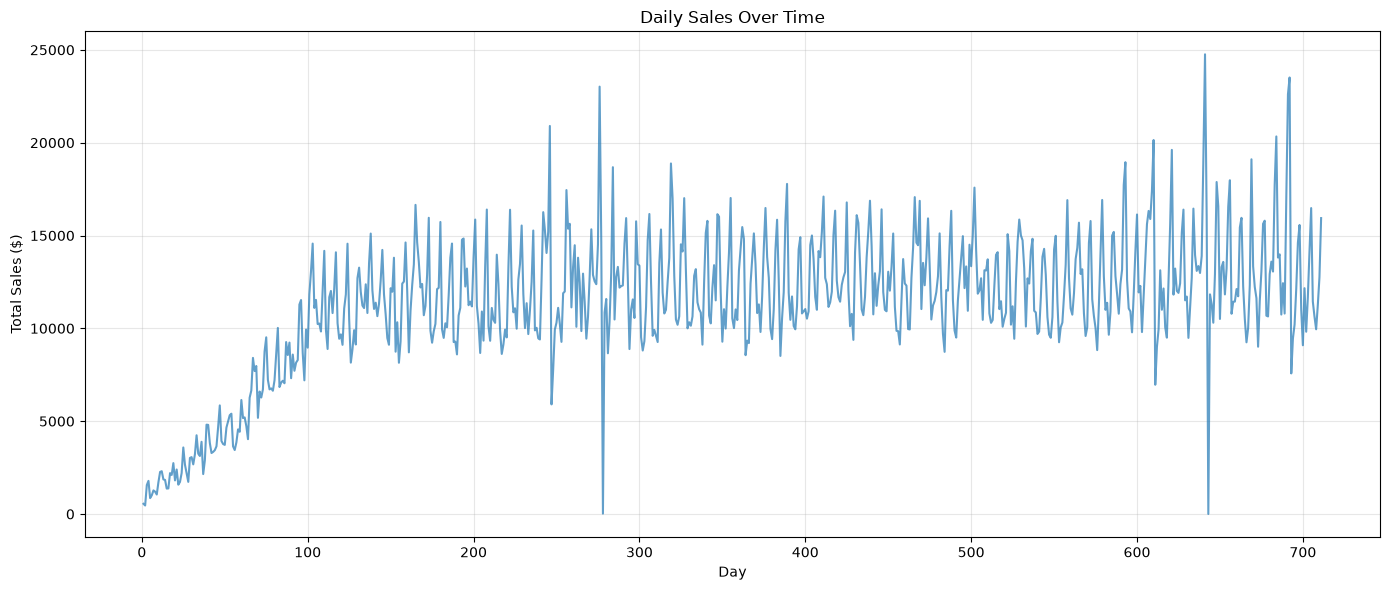

In [7]:
daily_sales = transactions.groupby('DAY')['SALES_VALUE'].sum().reset_index()
daily_sales.columns = ['day', 'sales']

plt.figure(figsize=(14, 6))
plt.plot(daily_sales['day'], daily_sales['sales'], alpha=0.7)
plt.title('Daily Sales Over Time')
plt.xlabel('Day')
plt.ylabel('Total Sales ($)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

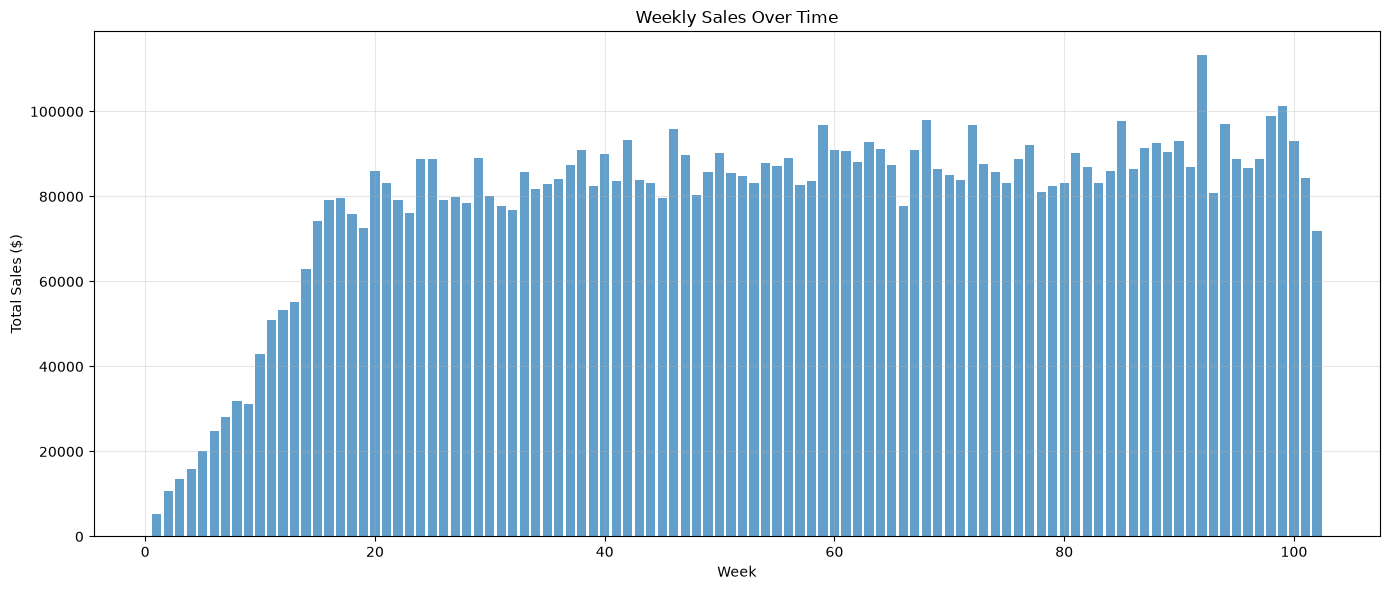

In [8]:
weekly_sales = transactions.groupby('WEEK_NO')['SALES_VALUE'].sum().reset_index()
weekly_sales.columns = ['week', 'sales']

plt.figure(figsize=(14, 6))
plt.bar(weekly_sales['week'], weekly_sales['sales'], alpha=0.7)
plt.title('Weekly Sales Over Time')
plt.xlabel('Week')
plt.ylabel('Total Sales ($)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

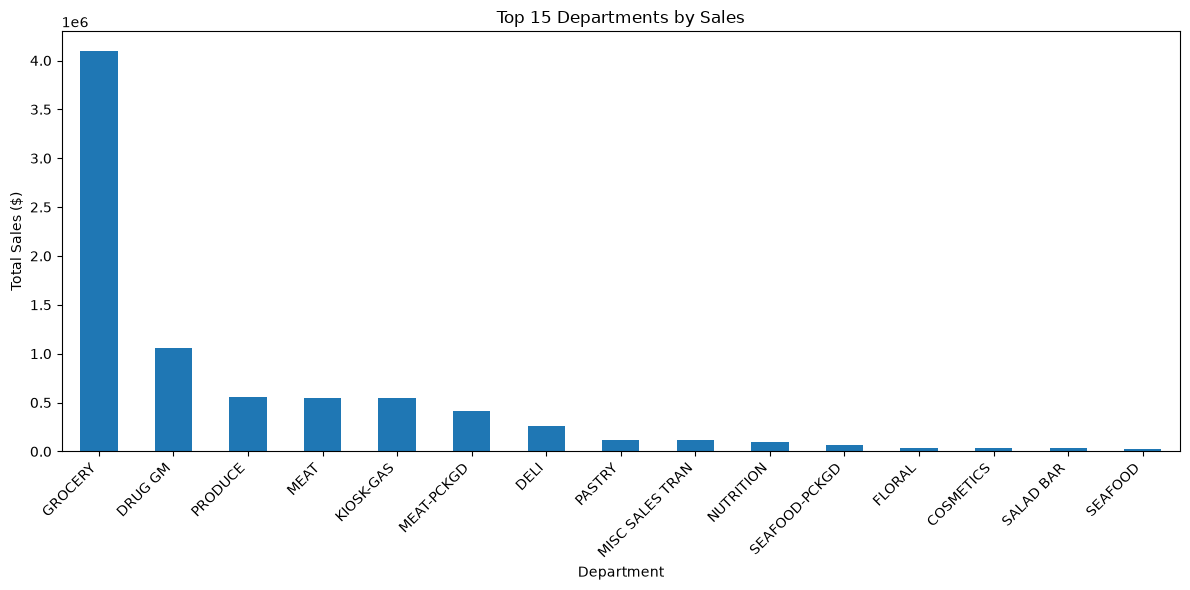

In [9]:
merged = transactions.merge(products[['PRODUCT_ID', 'DEPARTMENT', 'COMMODITY_DESC']], on='PRODUCT_ID', how='left')
dept_sales = merged.groupby('DEPARTMENT')['SALES_VALUE'].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 6))
dept_sales.plot(kind='bar')
plt.title('Top 15 Departments by Sales')
plt.xlabel('Department')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Promotion Analysis

In [10]:
print('=== Campaigns Overview ===')
campaign_desc['duration'] = campaign_desc['END_DAY'] - campaign_desc['START_DAY'] + 1
print(campaign_desc[['CAMPAIGN', 'DESCRIPTION', 'START_DAY', 'END_DAY', 'duration']].to_string())

=== Campaigns Overview ===
    CAMPAIGN DESCRIPTION  START_DAY  END_DAY  duration
0         24       TypeB        659      719        61
1         15       TypeC        547      708       162
2         25       TypeB        659      691        33
3         20       TypeC        615      685        71
4         23       TypeB        646      684        39
5         21       TypeB        624      656        33
6         22       TypeB        624      656        33
7         18       TypeA        587      642        56
8         19       TypeB        603      635        33
9         17       TypeB        575      607        33
10        14       TypeC        531      596        66
11        16       TypeB        561      593        33
12        13       TypeA        504      551        48
13        11       TypeB        477      523        47
14        12       TypeB        477      509        33
15        10       TypeB        463      495        33
16         9       TypeB        435   

In [11]:
discount_data = transactions[transactions['RETAIL_DISC'] < 0].copy()
discount_data['discount_pct'] = abs(discount_data['RETAIL_DISC']) / (discount_data['SALES_VALUE'] + abs(discount_data['RETAIL_DISC']))

print(f'Total transactions with discount: {len(discount_data):,}')
print(f'Discount rate stats:')
print(discount_data['discount_pct'].describe())

Total transactions with discount: 1,303,026
Discount rate stats:
count    1.303026e+06
mean     2.661108e-01
std      1.500900e-01
min      4.625933e-16
25%      1.567398e-01
50%      2.462312e-01
75%      3.710692e-01
max      1.000000e+00
Name: discount_pct, dtype: float64


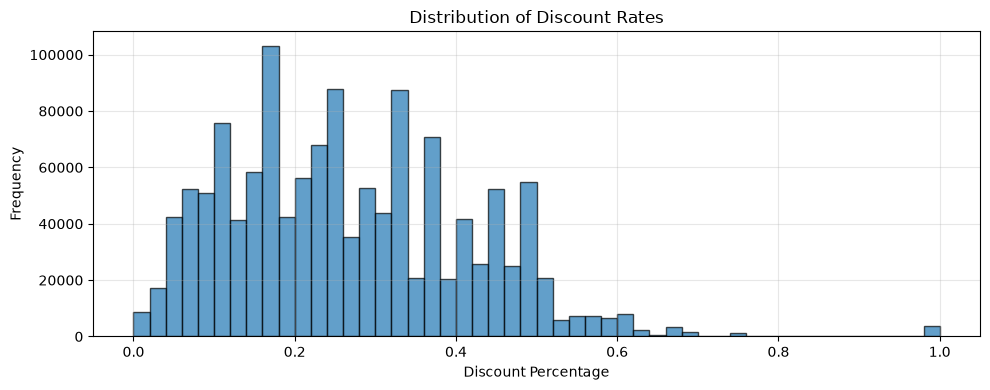

In [12]:
plt.figure(figsize=(10, 4))
plt.hist(discount_data['discount_pct'], bins=50, alpha=0.7, edgecolor='black')
plt.title('Distribution of Discount Rates')
plt.xlabel('Discount Percentage')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
camp_merged = campaign_desc.merge(campaign_table, on='CAMPAIGN', how='left')
print('Campaign-household mapping:')
print(camp_merged.groupby('CAMPAIGN')['household_key'].nunique().describe())

Campaign-product mapping:
count      30.000000
mean      240.266667
std       304.411579
min        12.000000
25%        69.000000
50%       173.000000
75%       221.500000
max      1133.000000
Name: household_key, dtype: float64


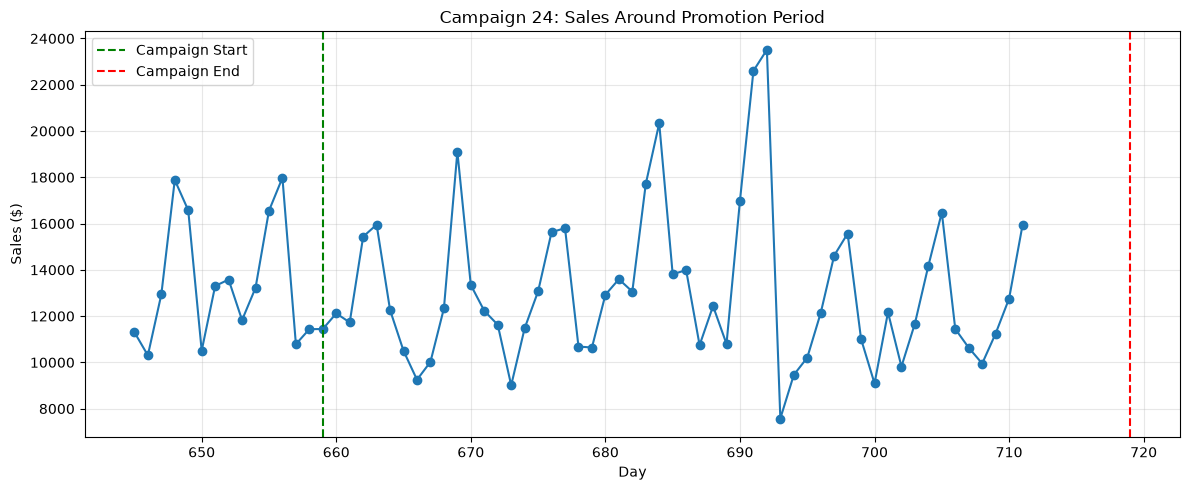

In [16]:
# Sales around a sample campaign period
camp = campaign_desc.iloc[0]
start, end = camp['START_DAY'], camp['END_DAY']

window = transactions[(transactions['DAY'] >= start - 14) & (transactions['DAY'] <= end + 14)]
window_sales = window.groupby('DAY')['SALES_VALUE'].sum().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(window_sales['DAY'], window_sales['SALES_VALUE'], marker='o')
plt.axvline(x=start, color='green', linestyle='--', label='Campaign Start')
plt.axvline(x=end, color='red', linestyle='--', label='Campaign End')
plt.title(f'Campaign {camp["CAMPAIGN"]}: Sales Around Promotion Period')
plt.xlabel('Day')
plt.ylabel('Sales ($)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
print('=== Key Insights ===')
print(f'Date range: {transactions["DAY"].min()} to {transactions["DAY"].max()}')
print(f'Number of products: {products["PRODUCT_ID"].nunique():,}')
print(f'Number of campaigns: {campaign_desc["CAMPAIGN"].nunique()}')
print(f'Total sales: ${transactions["SALES_VALUE"].sum():,.2f}')
print(f'Total transactions: {len(transactions):,}')

=== Key Insights ===
Date range: 1 to 711
Number of products: 92,353
Number of campaigns: 30
Total sales: $8,057,463.08
Total transactions: 2,595,732
